### Домашнє завдання: Пониження розмірностей для Аналізу Портретів Клієнтів

#### Контекст
В цьому ДЗ ми попрацюємо з методами пониження розмірності на наборі даних для задачі аналізу портретів клієнтів (Customer Personality Analysis). **В попередньому ДЗ ми працювали з цими даними використовуючи кластеризацію, зараз використаємо кластеризацію і візуалізауємо результати з різними методами.**

Customer Personality Analysis - це аналіз різних сегментів клієнтів компанії. Цей аналіз дозволяє бізнесу краще розуміти своїх клієнтів і полегшує процес адаптації продуктів під конкретні потреби, поведінку та інтереси різних типів клієнтів.

Аналіз портретів клієнтів допомагає бізнесу змінювати свій продукт на основі цільової аудиторії, розділеної на різні сегменти. Наприклад, замість того, щоб витрачати гроші на маркетинг нового продукту для всіх клієнтів у базі даних компанії, бізнес може проаналізувати, який сегмент клієнтів найімовірніше придбає продукт, і потім зосередити маркетингові зусилля лише на цьому сегменті.

#### Вхідні дані
Вам надано набір даних з такими атрибутами:

**Характеристики користувачів:**
- `ID`: Унікальний ідентифікатор клієнта
- `Year_Birth`: Рік народження клієнта
- `Education`: Рівень освіти клієнта
- `Marital_Status`: Сімейний стан клієнта
- `Income`: Річний дохід домогосподарства клієнта
- `Kidhome`: Кількість дітей у домогосподарстві клієнта
- `Teenhome`: Кількість підлітків у домогосподарстві клієнта
- `Dt_Customer`: Дата реєстрації клієнта у компанії
- `Recency`: Кількість днів з моменту останньої покупки клієнта
- `Complain`: 1, якщо клієнт скаржився за останні 2 роки, 0 - якщо ні

**Продукти:**
- `MntWines`: Сума, витрачена на вино за останні 2 роки
- `MntFruits`: Сума, витрачена на фрукти за останні 2 роки
- `MntMeatProducts`: Сума, витрачена на м'ясні продукти за останні 2 роки
- `MntFishProducts`: Сума, витрачена на рибні продукти за останні 2 роки
- `MntSweetProducts`: Сума, витрачена на солодощі за останні 2 роки
- `MntGoldProds`: Сума, витрачена на золото за останні 2 роки

**Акції:**
- `NumDealsPurchases`: Кількість покупок, зроблених з використанням знижок
- `AcceptedCmp1`: 1, якщо клієнт прийняв пропозицію у першій кампанії, 0 - якщо ні
- `AcceptedCmp2`: 1, якщо клієнт прийняв пропозицію у другій кампанії, 0 - якщо ні
- `AcceptedCmp3`: 1, якщо клієнт прийняв пропозицію у третій кампанії, 0 - якщо ні
- `AcceptedCmp4`: 1, якщо клієнт прийняв пропозицію у четвертій кампанії, 0 - якщо ні
- `AcceptedCmp5`: 1, якщо клієнт прийняв пропозицію у п'ятій кампанії, 0 - якщо ні
- `Response`: 1, якщо клієнт прийняв пропозицію в останній кампанії, 0 - якщо ні

**Взаємодія з компанією:**
- `NumWebPurchases`: Кількість покупок, зроблених через вебсайт компанії
- `NumCatalogPurchases`: Кількість покупок, зроблених за каталогом
- `NumStorePurchases`: Кількість покупок, зроблених безпосередньо у магазинах
- `NumWebVisitsMonth`: Кількість відвідувань вебсайту компанії за останній місяць


Для початку, запустіть код нижче. Всі ці кроки ми робили в попередньому ДЗ і для того, щоб результати кластеризації у нас були схожими, потрібно аби передобробка була однаковою.

In [24]:
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

In [4]:
# 1. Завантаження даних
df = pd.read_csv('../assets/hw_3_1/marketing_campaign.csv', sep='\t')

# 2. Обробка пропущених значень
df['Income_not_filled'] = df.Income.isna()
df.Income = df.Income.fillna(-1)

# 3. Обробка дати реєстрації
df.Dt_Customer = pd.to_datetime(df.Dt_Customer, format='%d-%m-%Y')
today = df.Dt_Customer.max()
df['days_lifetime'] = (today - df.Dt_Customer).dt.days
df['years_customer'] = df.Year_Birth.apply(lambda x: today.year - x)

# 4. Категоризація рівня освіти
df_education = pd.get_dummies(df.Education, prefix='education').astype(int)
df = pd.concat([df, df_education], axis=1)

# 5. Очищення сімейного стану
marital_status_map = {'Alone': 'Single', 'Absurd': 'Else', 'YOLO': 'Else'}
df['Marital_Status_clean'] = df.Marital_Status.map(marital_status_map)
df_ms = pd.get_dummies(df.Marital_Status_clean, prefix='marital').astype(int)
df = pd.concat([df, df_ms], axis=1)

# 6. Форматування доходу і видалення викиду
df.Income = df.Income.astype(int)
df = df[df.Income != 666666]

# 7. Створення фінального набору даних
X = df.drop(['ID', 'Dt_Customer', 'Education', 'Marital_Status', 'Marital_Status_clean'], axis=1)
X.reset_index(drop=True, inplace=True)

### Завдання 1: Виконання кластеризації та пониження розмірності для візуалізації результатів

Ваше завдання — провести кластеризацію клієнтів та візуалізувати результати кластеризації, використовуючи метод головних компонент (PCA) для пониження розмірності даних.

#### Інструкції:

1. **Вибір ключових характеристик:**
   Давайте обмежимось тільки наступними хараткеристиками для кластеризації цього разу:
   - `Income`: Річний дохід домогосподарства клієнта
   - `Recency`: Кількість днів з моменту останньої покупки клієнта
   - `NumStorePurchases`: Кількість покупок, зроблених безпосередньо у магазинах
   - `NumDealsPurchases`: Кількість покупок, зроблених з використанням знижок
   - `days_lifetime`: Кількість днів з моменту реєстрації клієнта у компанії
   - `years_customer`: Вік клієнта
   - `NumWebVisitsMonth`: Кількість відвідувань вебсайту компанії за останній місяць
   Відберіть в наборі даних `X` лише ці характеристики.

2. **Стандартизація даних:**
   Використайте метод `StandardScaler` для стандартизації значень обраних характеристик.
   
   **Чому не MinMaxScaler:**
   - Для PCA краще використовувати StandardScaler, бо він вирівнює дисперсію ознак, на відміну від MinMaxScaler, що просто масштабує значення без врахування варіації.

   - Для K-Means також краще використовувати StandardScaler, бо алгоритм чутливий до масштабів: фічі з більшими значеннями сильніше впливають на обчислення відстаней, що може спотворити кластери.

3. **Кластеризація:**
   Проведіть кластеризацію клієнтів, використовуючи метод `KMeans` з трьома кластерами.

4. **Пониження розмірності:**
   Використайте метод головних компонент (PCA) для пониження розмірності даних до трьох компонент.

5. **Візуалізація результатів:**
   Використовуючи plolty express побудуйте 3D-графік розподілу клієнтів у просторі трьох головних компонент, де кольором позначено кластери.

6. **Опишіть, що спостерігаєте:**
   Чи кластеризація чітко розділила дані?

Далі ми детальніше проінтерпретуємо результати візуалізації і пониження розмірностей.

In [15]:
features = [
    "Income",
    "Recency",
    "NumStorePurchases",
    "NumDealsPurchases",
    "days_lifetime",
    "years_customer",
    "NumWebVisitsMonth",
]

missing = [c for c in features if c not in X.columns]
if missing:
    raise ValueError(f"These required columns are missing in X: {missing}")

X_sel = X[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sel)

kmeans = KMeans(n_clusters=3, n_init="auto", random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)

pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X_scaled)
explained_var = pca.explained_variance_ratio_

plot_df = pd.DataFrame(X_pca, columns=["PC1", "PC2", "PC3"])
plot_df["cluster"] = cluster_labels.astype(str)
for c in ["Income", "Recency", "NumWebVisitsMonth"]:
    plot_df[c] = X_sel[c].values

cluster_sizes = pd.Series(cluster_labels).value_counts().sort_index()
print("Cluster sizes:", cluster_sizes.to_dict())
print(
    "PCA explained_variance_ratio_: "
    f"PC1={explained_var[0]:.3f}, PC2={explained_var[1]:.3f}, PC3={explained_var[2]:.3f}, "
    f"Total={explained_var.sum():.3f}"
)

fig = px.scatter_3d(
    plot_df,
    x="PC1", y="PC2", z="PC3",
    color="cluster",
    title="Customers clustered (KMeans, k=3) visualized in PCA 3D space",
    hover_data=["Income", "Recency", "NumWebVisitsMonth"]
)
fig.update_traces(marker=dict(size=4))
fig.show()

fig.write_html("../assets/hw_3_2/kmeans_pca_clusters.html")
print("HTML visualization saved to ../assets/hw_3_2/kmeans_pca_clusters.html")

df_clusters = X_sel.copy()
df_clusters["cluster"] = cluster_labels
means = df_clusters.groupby("cluster")[features].mean().round(2)
print("\nAverage feature values by cluster:")
print(means)


Cluster sizes: {0: 961, 1: 823, 2: 455}
PCA explained_variance_ratio_: PC1=0.318, PC2=0.197, PC3=0.143, Total=0.658


HTML visualization saved to ../assets/hw_3_2/kmeans_pca_clusters.html

Average feature values by cluster:
           Income  Recency  NumStorePurchases  NumDealsPurchases  \
cluster                                                            
0        33061.01    48.51               3.18               1.81   
1        72551.55    49.35               8.34               1.44   
2        51937.72    50.01               6.70               5.00   

         days_lifetime  years_customer  NumWebVisitsMonth  
cluster                                                    
0               312.30           41.92               6.51  
1               315.25           47.35               3.07  
2               510.01           48.23               6.87  


## Summary

### **1. PCA Overview**
The PCA transformation explains **65.8% of total variance** across the first three principal components
(**PC1 = 0.318**, **PC2 = 0.197**, **PC3 = 0.143**).
This indicates a solid dimensionality reduction — the 3D PCA visualization retains most of the structure of the original data.

---

### **2. Cluster Composition**
The clustering divided the dataset into **three distinct customer groups**:

- **Cluster 0 (961 samples)** — Low-income, low-purchase group with the fewest store purchases and relatively frequent web visits.
- **Cluster 1 (823 samples)** — High-income, high-engagement customers with the largest number of store purchases and the fewest website visits; likely **loyal, high-value customers**.
- **Cluster 2 (455 samples)** — Mid-income customers with moderate store activity but the **highest number of deal purchases**, suggesting a **price-sensitive, promotion-driven segment**.

---

### **3. Average Feature Values by Cluster**

| Feature | Cluster 0 | Cluster 1 | Cluster 2 | Key Trend |
|----------|------------|------------|------------|------------|
| **Income** | 33,061 | 72,552 | 51,938 | Cluster 1 shows clearly higher income |
| **NumStorePurchases** | 3.18 | 8.34 | 6.70 | Strong in-store activity in Cluster 1 |
| **NumDealsPurchases** | 1.81 | 1.44 | 5.00 | Cluster 2 is the most discount-driven |
| **NumWebVisitsMonth** | 6.51 | 3.07 | 6.87 | Cluster 1 prefers offline interaction |

---

### **4. Business Interpretation**
- **Cluster 0 — Passive / low-income clients:** infrequent buyers, moderate online activity.
- **Cluster 1 — Premium loyal clients:** high-income, consistent in-store shoppers.
- **Cluster 2 — Deal seekers:** mid-income, promotion-sensitive customers with higher web engagement.

These three clusters can guide **personalized marketing strategies** — for example:
- Retarget Cluster 0 with awareness campaigns,
- Reward Cluster 1 with loyalty benefits,
- Offer Cluster 2 limited-time discounts or bundle promotions.



### Завдання 2: Аналіз результатів пониження розмірності

1. **Розрахунок частки поясненої дисперсії:**
   Визначте, яка частка загальної варіації даних пояснюється кожною з трьох головних компонент (PC1, PC2, PC3) за допомогою атрибуту `explained_variance_ratio_` об'єкта PCA. Виведіть результат на екран.

2. **Розрахунок кумулятивної частки поясненої дисперсії:**
   Обчисліть кумулятивну частку поясненої дисперсії для трьох головних компонент, щоб зрозуміти, скільки варіації даних пояснюється першими кількома компонентами.

In [16]:
explained_var = pca.explained_variance_ratio_

print("Explained variance by component:")
for i, var in enumerate(explained_var, start=1):
    print(f"PC{i}: {var:.3f}")

cumulative_var = explained_var.cumsum()
print("\nCumulative explained variance:")
for i, cum in enumerate(cumulative_var, start=1):
    print(f"Up to PC{i}: {cum:.3f}")


Explained variance by component:
PC1: 0.318
PC2: 0.197
PC3: 0.143

Cumulative explained variance:
Up to PC1: 0.318
Up to PC2: 0.515
Up to PC3: 0.658


### Summary

The first principal component (PC1) explains **31.8%** of the total variance, PC2 explains **19.7%**, and PC3 explains **14.3%**.
Together, the three components capture **65.8% of the total data variability**, indicating that most of the structure and information from the original dataset is preserved after dimensionality reduction to 3 components.


### Завдання 3: Інтерпретація "Loadings"

Продовжуємо інтерпретацію результатів `PCA`і познайомимось з новим поняттям `loadings`, яке допоможе нам знайти звʼязок між головними компонентами і оригінальними ознаками в наборі даних.

Ми зараз побудували візуалізацію кластерів точок даних в просторі трьох головних компонент. Але хочеться знайти звʼязок між головними компонентами і оригінальними ознаками. Для розуміння, які початкові характеристики даних мають найбільший вплив на ці головні компоненти, ми можемо використати атрибут `components_` методу `PCA`.

#### Що таке `pca.components_`?

`pca.components_` — це масив, який містить коефіцієнти (або "ваги"), що показують внесок кожної вихідної ознаки у кожну з головних компонент. Ці коефіцієнти ще називаються **"loading"** або "навантаженнями" компонент.

- **Loadings** (`навантаження`) відображають важливість кожної змінної (ознаки) для відповідної головної компоненти. Вони показують, яким чином змінні поєднуються, щоб утворити нові, зменшені вимірювання.
- Якщо коефіцієнт має високе абсолютне значення (як позитивне, так і негативне), це вказує на те, що відповідна змінна сильно впливає на головну компоненту.

#### Саме завдання
Ваше завдання — обчислити "навантаження" для кожної з головних компонент і інтерпретувати результати.

1. **Обчислення loadings для компонент:**
   Використайте атрибут `components_` об'єкта PCA для створення DataFrame, який відображатиме внесок кожної вихідної ознаки в кожну головну компоненту.

2. **Інтерпретація результатів:**
   Виведіть значення "навантажень" і проаналізуйте, які ознаки найбільше впливають на кожну головну компоненту.

In [17]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2", "PC3"],
    index=features
).round(3)

print("PCA Loadings (feature contributions to each principal component):")
print(loadings)

for pc in loadings.columns:
    top_features = loadings[pc].abs().sort_values(ascending=False).head(3).index.tolist()
    print(f"\nTop features influencing {pc}: {', '.join(top_features)}")

PCA Loadings (feature contributions to each principal component):
                     PC1    PC2    PC3
Income             0.584  0.165 -0.044
Recency            0.010  0.037  0.976
NumStorePurchases  0.489  0.385 -0.081
NumDealsPurchases -0.199  0.608 -0.035
days_lifetime     -0.133  0.603 -0.022
years_customer     0.189  0.209  0.193
NumWebVisitsMonth -0.572  0.216 -0.016

Top features influencing PC1: Income, NumWebVisitsMonth, NumStorePurchases

Top features influencing PC2: NumDealsPurchases, days_lifetime, NumStorePurchases

Top features influencing PC3: Recency, years_customer, NumStorePurchases


## Summary

The **PCA loadings** show how much each original feature contributes to the first three principal components.
High absolute values indicate a stronger influence on that component’s meaning.

---

### **1. PC1 – Financial & Engagement Component**
- **Top features:** `Income`, `NumWebVisitsMonth`, `NumStorePurchases`
- **Interpretation:**
  PC1 contrasts **high income and in-store purchase frequency** (positive loadings)
  with **web activity** (negative loading).
  This suggests that PC1 captures a dimension of **financial engagement vs. online browsing**,
  where higher values correspond to **wealthier, store-oriented customers**.

---

### **2. PC2 – Discount & Tenure Component**
- **Top features:** `NumDealsPurchases`, `days_lifetime`, `NumStorePurchases`
- **Interpretation:**
  This component combines **deal-based activity** and **customer longevity**.
  It reflects a dimension of **long-term engagement and responsiveness to promotions** —
  customers with high PC2 scores tend to be **experienced, deal-aware buyers**.

---

### **3. PC3 – Recency Component**
- **Top features:** `Recency`, `years_customer`, `NumStorePurchases`
- **Interpretation:**
  PC3 is dominated by **Recency (0.976)**, indicating that it almost entirely represents
  **how recently a customer made a purchase**.
  Higher PC3 values correspond to **less recent or inactive customers**.

---

### **Overall Insight**
- **PC1 (32%)** → differentiates **high-income, offline buyers** from **online visitors**.
- **PC2 (20%)** → represents **loyal, promotion-sensitive customers**.
- **PC3 (14%)** → captures **purchase recency and activity freshness**.

Together, these components summarize **financial strength, promotional behavior, and engagement recency** —
the key behavioral dimensions of the customer base.


###Завдання 4
Давайте проаналізуємо "навантаження" (**loadings**) для трьох головних компонент після вилучення ознаки `Income`. Це допоможе нам зрозуміти, як змінилася важливість інших ознак для кожної головної компоненти, коли одна з ключових характеристик (`Income`) була вилучена.

#### Кроки для проведення аналізу і ваше завдання:

1. Видаліть ознаку `Income` з нашого набору даних `X` і повторно виконайте PCA (метод головних компонент) для отримання нових "навантажень".

2. Обчисліть нові "навантаження" для трьох головних компонент на наборі даних без `Income`

3. Проаналізуйте, які ознаки мають найбільший вплив на кожну головну компоненту після вилучення `Income`.

4. Перегляньте, наскільки кожна з головних компонент пояснює дисперсію в даних без ознаки `Income`.

In [18]:
features_no_income = [f for f in features if f != "Income"]

X_no_income = X[features_no_income].copy()

scaler = StandardScaler()
X_scaled_no_income = scaler.fit_transform(X_no_income)

pca_no_income = PCA(n_components=3, random_state=42)
X_pca_no_income = pca_no_income.fit_transform(X_scaled_no_income)

explained_var_no_income = pca_no_income.explained_variance_ratio_

print("Explained variance by component (without Income):")
for i, var in enumerate(explained_var_no_income, start=1):
    print(f"PC{i}: {var:.3f}")
print(f"Total explained variance: {explained_var_no_income.sum():.3f}")

loadings_no_income = pd.DataFrame(
    pca_no_income.components_.T,
    columns=["PC1", "PC2", "PC3"],
    index=features_no_income
).round(3)

print("\nPCA Loadings without Income:")
print(loadings_no_income)

for pc in loadings_no_income.columns:
    top_features = loadings_no_income[pc].abs().sort_values(ascending=False).head(3).index.tolist()
    print(f"\nTop features influencing {pc}: {', '.join(top_features)}")

Explained variance by component (without Income):
PC1: 0.274
PC2: 0.214
PC3: 0.167
Total explained variance: 0.655

PCA Loadings without Income:
                     PC1    PC2    PC3
Recency           -0.014  0.075  0.990
NumStorePurchases -0.381  0.629 -0.111
NumDealsPurchases  0.446  0.462 -0.062
days_lifetime      0.384  0.468  0.007
years_customer    -0.177  0.394  0.056
NumWebVisitsMonth  0.691 -0.108  0.010

Top features influencing PC1: NumWebVisitsMonth, NumDealsPurchases, days_lifetime

Top features influencing PC2: NumStorePurchases, days_lifetime, NumDealsPurchases

Top features influencing PC3: Recency, NumStorePurchases, NumDealsPurchases


## Summary

After excluding the `Income` feature, the structure of the principal components changed noticeably:

- **PC1 (NumWebVisitsMonth, NumDealsPurchases, days_lifetime):**
  Now dominated by **web activity and deal-related behavior**, indicating that without income,
  the first component captures **online engagement and promotion sensitivity** rather than financial status.

- **PC2 (NumStorePurchases, days_lifetime, NumDealsPurchases):**
  Focuses on **store activity and customer tenure**, representing **loyalty and shopping intensity**.

- **PC3 (Recency, NumStorePurchases, NumDealsPurchases):**
  Still primarily defined by **Recency (0.990)**, showing this axis continues to reflect **time since last purchase**.

**Overall effect:**
Removing `Income` shifted PCA emphasis from **financial segmentation** (previously dominant in PC1)
to **behavioral and engagement-based factors** — such as **web activity, store visits, and deal usage**.
The components now describe **customer behavior patterns** rather than **spending capacity**.


### Завдання 5: Візуалізація кластеризації за допомогою t-SNE

Ваше завдання — використати метод t-SNE для візуалізації результатів кластеризації клієнтів у двовимірному просторі. Метод t-SNE допомагає знизити розмірність даних та зберегти локальні структури в даних, що робить його ефективним для візуалізації високорозмірних даних. Ми також зможемо порівняти результат цього методу з РСА.

1. Використайте метод t-SNE для зниження розмірності до 2х вимірів даних, які включають ознаки всі, що і в завданні 1, а також були відмасштабовані перед пониженням розмірностей.

2. Створіть новий DataFrame з координатами, отриманими після застосування t-SNE, та додайте до нього мітки кластерів.

3. Побудуйте інтерактивний 2D-графік розподілу клієнтів, де кольором буде позначено різні кластери і проаналізуйте графік з рекомендаціями нижче (можливо треба буде вивести додаткові візуалізації чи таблиці для інтерпретації, але треба прям зрозуміти, які ознаки формують який кластер і чим кластери відрізняються одне від одного).

  **Опишіть отримані кластери з точки зору ознак.**

4. Опишіть відмінність графіка tSNE від PCA.

#### ЯК можна інтерпретувати з t-SNE?

Хоча t-SNE не надає "компонентів" як РСА, він забезпечує низьковимірне представлення даних, яке можна візуально інтерпретувати:

- **Кластери:** t-SNE особливо добре показує кластери подібних точок. Якщо ви бачите чітко визначені кластери на графіку t-SNE, це свідчить про наявність груп схожих спостережень у ваших даних. Проаналізувати їх можемо, якщо додамо дані в `hover_data` або якщо якісь з даних виведемо як розмір чи форма точок на візуалізації. Також корисно може бути вивести середні значення ознак по кластерам.
- **Локальна структура:** Відносне розташування точок одного кластеру на графіку t-SNE може допомогти вам зрозуміти, які дані подібні між собою.
- **Глобальна структура:** Будьте обережні; t-SNE менш надійний для відображення глобальних структур (наприклад, відстаней між кластерами) у порівнянні з PCA, бо t-SNE націлений на збереження саме локальних структур.

t-SNE visualization saved to ../assets/hw_3_2/tsne_clusters.html

Average feature values by cluster:
           Income  Recency  NumStorePurchases  NumDealsPurchases  \
cluster                                                            
0        33061.01    48.51               3.18               1.81   
1        72551.55    49.35               8.34               1.44   
2        51937.72    50.01               6.70               5.00   

         days_lifetime  years_customer  NumWebVisitsMonth  
cluster                                                    
0               312.30           41.92               6.51  
1               315.25           47.35               3.07  
2               510.01           48.23               6.87  


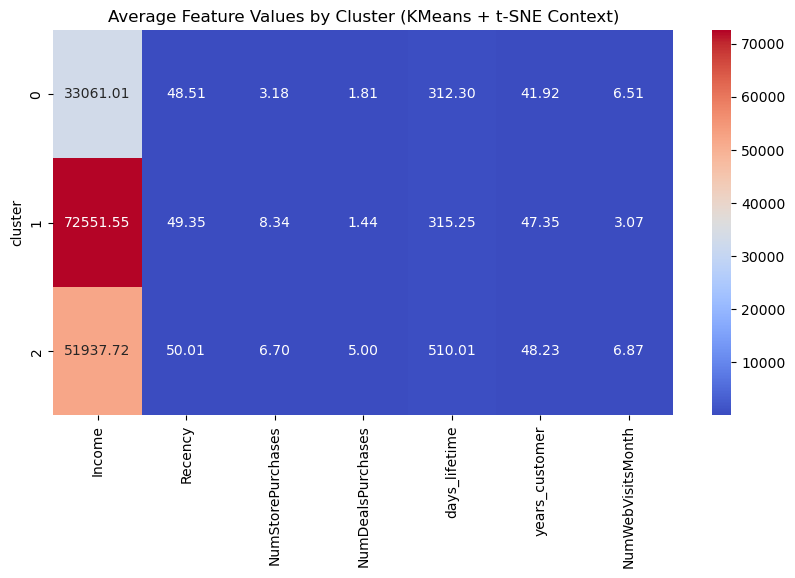

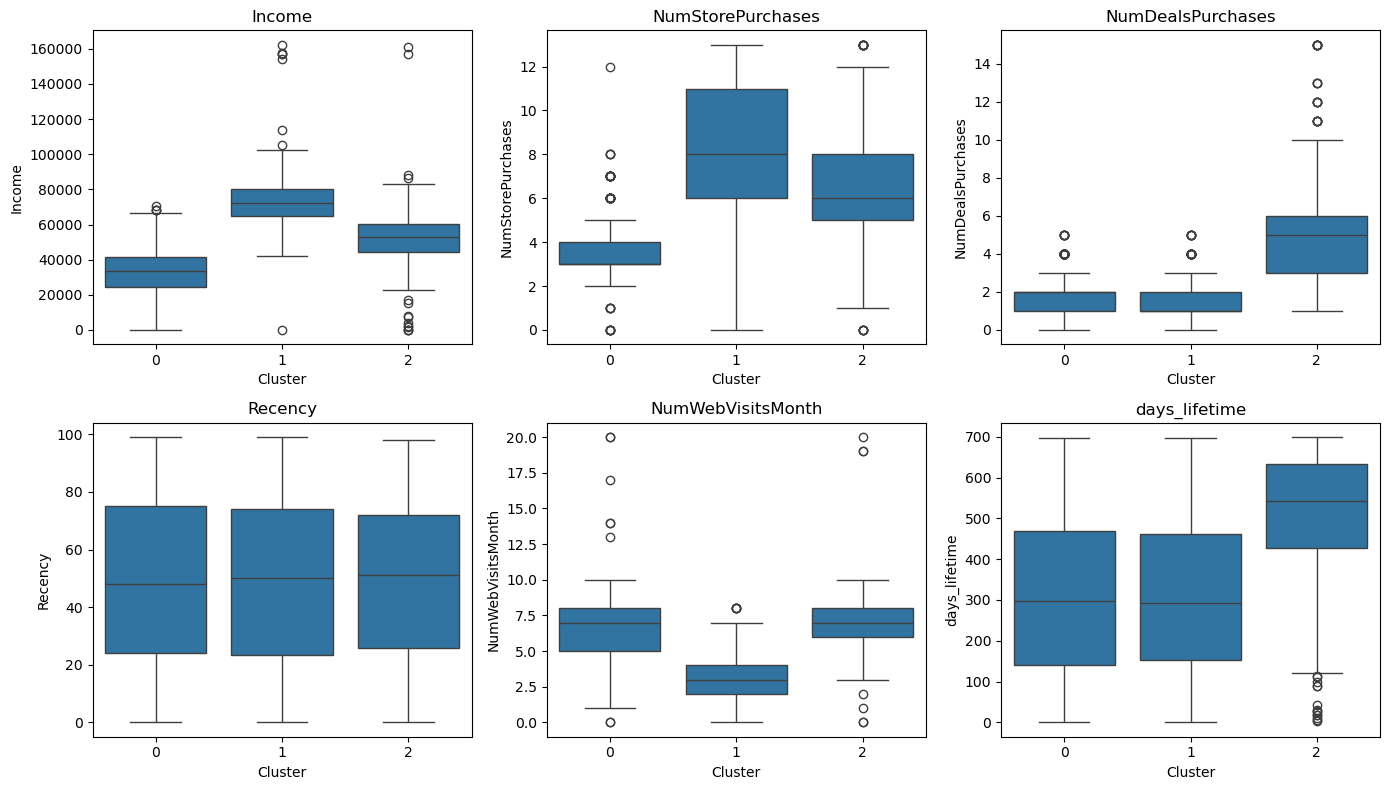

In [25]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    max_iter=1000,
    random_state=42
)

X_tsne = tsne.fit_transform(X_scaled)

tsne_df = pd.DataFrame(X_tsne, columns=["TSNE1", "TSNE2"])
tsne_df["cluster"] = cluster_labels.astype(str)
tsne_df[["Income", "Recency", "NumStorePurchases", "NumDealsPurchases"]] = X_sel[
    ["Income", "Recency", "NumStorePurchases", "NumDealsPurchases"]
]

fig = px.scatter(
    tsne_df,
    x="TSNE1", y="TSNE2",
    color="cluster",
    title="t-SNE Visualization of Customer Clusters (k=3)",
    hover_data=["Income", "Recency", "NumStorePurchases", "NumDealsPurchases"]
)
fig.update_traces(marker=dict(size=6, opacity=0.8))
fig.show()

fig.write_html("../assets/hw_3_2/tsne_clusters.html")
print("t-SNE visualization saved to ../assets/hw_3_2/tsne_clusters.html")

cluster_means = X_sel.copy()
cluster_means["cluster"] = cluster_labels
cluster_means = cluster_means.groupby("cluster")[features].mean().round(2)
print("\nAverage feature values by cluster:")
print(cluster_means)

plt.figure(figsize=(10, 5))
sns.heatmap(cluster_means, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Average Feature Values by Cluster (KMeans + t-SNE Context)")
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
selected_cols = ["Income", "NumStorePurchases", "NumDealsPurchases", "Recency", "NumWebVisitsMonth", "days_lifetime"]

for i, col in enumerate(selected_cols):
    sns.boxplot(x=cluster_labels, y=X_sel[col], ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel("Cluster")
plt.tight_layout()
plt.show()

## Summary

### **1. Cluster Structure (t-SNE Plot)**
The t-SNE projection shows **three clearly distinguishable clusters**, confirming the same segmentation pattern seen earlier with PCA.
Clusters are well-separated along both TSNE1 and TSNE2 axes, indicating stable group formation based on customer behavior and spending habits.

---

### **2. Cluster Profiles (based on feature averages and boxplots)**

| Cluster | Income | NumStorePurchases | NumDealsPurchases | NumWebVisitsMonth | days_lifetime | Key Characteristics |
|----------|---------|------------------|-------------------|-------------------|---------------|----------------------|
| **0** | 33 061 | 3.18 | 1.81 | 6.51 | 312 | Low-income, low store activity, frequent web visits — **passive / online-oriented customers** |
| **1** | 72 552 | 8.34 | 1.44 | 3.07 | 315 | High-income, very active in stores, minimal online interaction — **loyal premium shoppers** |
| **2** | 51 938 | 6.70 | 5.00 | 6.87 | 510 | Mid-income, high deal usage, longest lifetime — **experienced deal-seekers** |

Boxplots confirm these distinctions:
- **Cluster 1** shows the highest medians for *Income* and *NumStorePurchases* — the wealthiest and most active buyers.
- **Cluster 2** exhibits a clear spike in *NumDealsPurchases* and *days_lifetime* — long-term customers who react to promotions.
- **Cluster 0** has generally lower values across metrics but higher *NumWebVisitsMonth*, indicating interest without frequent purchases.

---

### **3. Insights**
- **Cluster 1 — Premium Loyal Customers:** High spenders with consistent in-store purchases and minimal online browsing.
- **Cluster 2 — Deal-Driven Customers:** Moderately wealthy, long-standing clients responding strongly to discounts and offers.
- **Cluster 0 — Passive Online Users:** Low-income customers with low engagement but frequent website activity.

---

### **4. Comparison: t-SNE vs PCA**
- **PCA** focuses on *global variance* and provides interpretable axes (financial vs behavioral dimensions).
- **t-SNE**, by contrast, preserves *local relationships*, highlighting the compactness and separation of clusters more clearly.
- The t-SNE visualization emphasizes **within-cluster cohesion and boundary clarity**, complementing PCA’s interpretability with a more intuitive view of group separation.

---

**Overall conclusion:**
t-SNE confirms a consistent three-segment structure among customers, where clusters differ mainly by **income level, store engagement, and sensitivity to discounts** — insights that can guide tailored marketing strategies.
